In [43]:
import json

import gc_utils
import gizmo_analysis as gizmo
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
from matplotlib import colors

In [44]:
sim = "m12i"
sim_dir = "/Users/z5114326/Documents/simulations/extra_snaps/"

snap_dict = {"m12b": 177, "m12c": 227, "m12f": 174, "m12i": 256, "m12m": 222}

In [45]:
fire_dir = sim_dir + sim + "/" + sim + "_res7100/"
part = gc_utils.open_snapshot(snap_dict[sim], fire_dir, species=["star", "gas", "dark"])

Retrieving Snapshot 256..................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:49<00:00, 49.20s/it]


In [46]:
def compute_and_plot_hist(x, y, mass, bins, limits, ax):
    hist, x_edges, y_edges = np.histogram2d(x, y, bins=bins, range=limits, weights=mass)
    hist /= np.diff(x_edges)[0] * np.diff(y_edges)[0]
    hist = np.nan_to_num(hist, nan=0)
    min_pos = hist[hist > 0].min()
    hist[hist == 0] = min_pos
    im = ax.imshow(
        hist.T,
        norm=colors.LogNorm(),
        cmap=color_map,
        aspect="auto",
        interpolation="bilinear",
        extent=np.concatenate(limits),
    )
    return im

Text(0.5, 1.0, 'Dark Matter')

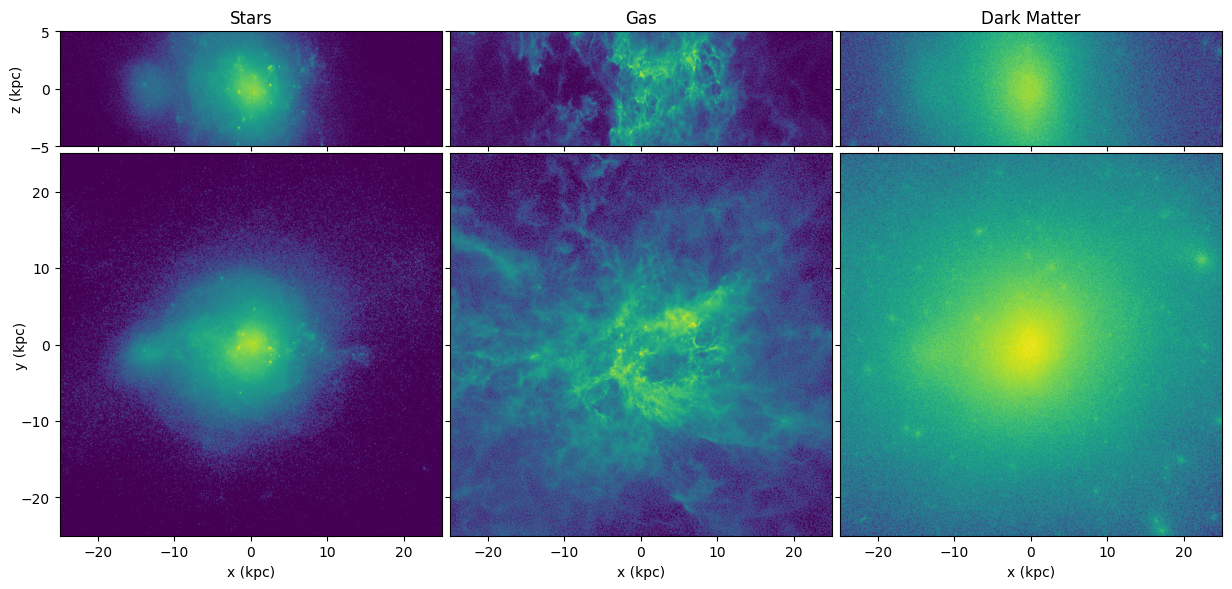

In [47]:
r_lim = 25
distance_bin_width = 0.1
position_bin_number = int(np.round(2 * np.max(r_lim) / distance_bin_width))

sta_dis = part["star"].prop("host.distance.principal.total")
sta_dis_msk = sta_dis <= 2 * r_lim
sta_pos = part["star"].prop("host.distance.principal")[sta_dis_msk]
sta_mas = part["star"]["mass"][sta_dis_msk]

gas_dis = part["gas"].prop("host.distance.principal.total")
gas_dis_msk = gas_dis <= 2 * r_lim
gas_pos = part["gas"].prop("host.distance.principal")[gas_dis_msk]
gas_mas = part["gas"]["mass"][gas_dis_msk]

dar_dis = part["dark"].prop("host.distance.principal.total")
dar_dis_msk = dar_dis <= 2 * r_lim
dar_pos = part["dark"].prop("host.distance.principal")[dar_dis_msk]
dar_mas = part["dark"]["mass"][dar_dis_msk]


# Adjustable ratio of bottom row height vs top row height
height_ratio = 2

fig = plt.figure(figsize=(15, 9))
gs = fig.add_gridspec(2, 3, height_ratios=[1, height_ratio])
color_map = plt.cm.viridis


axs = [
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])],
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1]), fig.add_subplot(gs[1, 2])],
]

#######################################################################
# star x, y (bottom left)
position_limits = np.array([[-r_lim, r_lim], [-r_lim, r_lim]])
compute_and_plot_hist(sta_pos[:, 0], sta_pos[:, 1], sta_mas, position_bin_number, position_limits, axs[1][0])

# # star x, z (top left)
position_limits = np.array([[-r_lim, r_lim], [-5, 5]])
compute_and_plot_hist(sta_pos[:, 0], sta_pos[:, 2], sta_mas, position_bin_number, position_limits, axs[0][0])
#######################################################################

#######################################################################
# # gas x, y (bottom right)
position_limits = np.array([[-r_lim, r_lim], [-r_lim, r_lim]])
compute_and_plot_hist(gas_pos[:, 0], gas_pos[:, 1], gas_mas, position_bin_number, position_limits, axs[1][1])

# # gas x, z (top right)
position_limits = np.array([[-r_lim, r_lim], [-5, 5]])
compute_and_plot_hist(gas_pos[:, 0], gas_pos[:, 2], gas_mas, position_bin_number, position_limits, axs[0][1])
#######################################################################

#######################################################################
# # dar x, y (bottom right)
position_limits = np.array([[-r_lim, r_lim], [-r_lim, r_lim]])
compute_and_plot_hist(dar_pos[:, 0], dar_pos[:, 1], dar_mas, position_bin_number, position_limits, axs[1][2])

# # dar x, z (top right)
position_limits = np.array([[-r_lim, r_lim], [-5, 5]])
compute_and_plot_hist(dar_pos[:, 0], dar_pos[:, 2], dar_mas, position_bin_number, position_limits, axs[0][2])
#######################################################################

# # Set aspect ratios
axs[0][0].set_aspect(1.5)  # top left rectangular
axs[0][1].set_aspect(1.5)  # top right rectangular
axs[0][2].set_aspect(1.5)  # top right rectangular

axs[1][0].set_aspect(1)  # bottom left square
axs[1][1].set_aspect(1)  # bottom right square
axs[1][2].set_aspect(1)  # bottom right square

axs[0][0].set_xticklabels([])
axs[0][1].set_xticklabels([])
axs[0][2].set_xticklabels([])

axs[0][1].set_yticklabels([])
axs[0][2].set_yticklabels([])

axs[1][1].set_yticklabels([])
axs[1][2].set_yticklabels([])


# Adjust spacing
plt.subplots_adjust(hspace=-0.415, wspace=0.02)

axs[0][0].set_xticks([-20, -10, 0, 10, 20])
axs[0][1].set_xticks([-20, -10, 0, 10, 20])
axs[0][2].set_xticks([-20, -10, 0, 10, 20])

axs[1][0].set_xticks([-20, -10, 0, 10, 20])
axs[1][1].set_xticks([-20, -10, 0, 10, 20])
axs[1][2].set_xticks([-20, -10, 0, 10, 20])


axs[0][0].set_yticks([-5, 0, 5])
axs[0][1].set_yticks([-5, 0, 5])
axs[0][2].set_yticks([-5, 0, 5])


axs[1][0].set_yticks([-20, -10, 0, 10, 20])
axs[1][1].set_yticks([-20, -10, 0, 10, 20])
axs[1][2].set_yticks([-20, -10, 0, 10, 20])


axs[0][0].set_ylabel("z (kpc)")

axs[1][0].set_xlabel("x (kpc)")
axs[1][0].set_ylabel("y (kpc)", labelpad=-5)

axs[1][1].set_xlabel("x (kpc)")
axs[1][2].set_xlabel("x (kpc)")

axs[0][0].set_title("Stars")
axs[0][1].set_title("Gas")
axs[0][2].set_title("Dark Matter")